In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import folium

In [4]:
df = pd.read_csv('/content/drive/MyDrive/chennaiproject/project/MOD11A2-061-results.csv')

In [5]:
print(df.shape)
print(df.head())
print(df.columns.tolist())

(1380, 18)
             ID  Latitude  Longitude        Date MODIS_Tile  \
0  chennaicoast     13.05       80.3  2018-12-27     h25v07   
1  chennaicoast     13.05       80.3  2019-01-01     h25v07   
2  chennaicoast     13.05       80.3  2019-01-09     h25v07   
3  chennaicoast     13.05       80.3  2019-01-17     h25v07   
4  chennaicoast     13.05       80.3  2019-01-25     h25v07   

   MOD11A2_061_Line_Y_1km  MOD11A2_061_Sample_X_1km  MOD11A2_061_LST_Day_1km  \
0                   833.0                     987.0                      0.0   
1                   833.0                     987.0                      0.0   
2                   833.0                     987.0                      0.0   
3                   833.0                     987.0                      0.0   
4                   833.0                     987.0                      0.0   

   MOD11A2_061_QC_Day MOD11A2_061_QC_Day_bitmask MOD11A2_061_QC_Day_MODLAND  \
0                 3.0                 0b00000011  

In [6]:
df_clean = df[df['MOD11A2_061_LST_Day_1km'] > 0].copy()

In [7]:
df_clean['LST_Celsius'] = (df_clean['MOD11A2_061_LST_Day_1km'] * 0.02) - 273.15

In [8]:
df_clean['Date'] = pd.to_datetime(df_clean['Date'])
df_clean['Year'] = df_clean['Date'].dt.year
df_clean['Month'] = df_clean['Date'].dt.month

In [9]:
df_clean = df_clean[df_clean['MOD11A2_061_QC_Day_Data_Quality_flag_Description'] == 'Good data quality']

In [10]:
print(f"Original rows: {len(df)}")
print(f"Clean rows: {len(df_clean)}")
print(df_clean[['ID', 'Date', 'LST_Celsius']].head(10))

Original rows: 1380
Clean rows: 800
               ID       Date  LST_Celsius
277  chennaigreen 2019-01-01    -267.0820
278  chennaigreen 2019-01-09    -267.0752
279  chennaigreen 2019-01-17    -267.0604
280  chennaigreen 2019-01-25    -267.0612
281  chennaigreen 2019-02-02    -267.0256
282  chennaigreen 2019-02-10    -267.0296
283  chennaigreen 2019-02-18    -266.9640
284  chennaigreen 2019-02-26    -266.9844
285  chennaigreen 2019-03-06    -266.9528
286  chennaigreen 2019-03-14    -266.9228


In [11]:
df_clean = df[df['MOD11A2_061_LST_Day_1km'] > 7500].copy()

In [12]:
df_clean['LST_Celsius'] = (df_clean['MOD11A2_061_LST_Day_1km'] * 0.02) - 273.15

In [13]:
df_clean['Date'] = pd.to_datetime(df_clean['Date'])
df_clean['Year'] = df_clean['Date'].dt.year
df_clean['Month'] = df_clean['Date'].dt.month

In [14]:
df_clean = df_clean[df_clean['MOD11A2_061_QC_Day_Data_Quality_flag_Description'] == 'Good data quality']


In [15]:
print(f"Original rows: {len(df)}")
print(f"Clean rows: {len(df_clean)}")
print(f"Min temp: {df_clean['LST_Celsius'].min():.2f}°C")
print(f"Max temp: {df_clean['LST_Celsius'].max():.2f}°C")
print(df_clean[['ID', 'Date', 'LST_Celsius']].head(10))

Original rows: 1380
Clean rows: 0
Min temp: nan°C
Max temp: nan°C
Empty DataFrame
Columns: [ID, Date, LST_Celsius]
Index: []


In [16]:
# Diagnostic - let's see the actual range of raw LST values
print("Raw LST value stats:")
print(df['MOD11A2_061_LST_Day_1km'].describe())

print("\nUnique Data_Quality_flag descriptions:")
print(df['MOD11A2_061_QC_Day_Data_Quality_flag_Description'].value_counts())

print("\nSample of rows where LST > 1000:")
print(df[df['MOD11A2_061_LST_Day_1km'] > 1000][['ID','Date','MOD11A2_061_LST_Day_1km']].head(10))

Raw LST value stats:
count    1380.000000
mean      178.436174
std       152.011413
min         0.000000
25%         0.000000
50%       303.630000
75%       308.905000
max       319.180000
Name: MOD11A2_061_LST_Day_1km, dtype: float64

Unique Data_Quality_flag descriptions:
MOD11A2_061_QC_Day_Data_Quality_flag_Description
Good data quality    1380
Name: count, dtype: int64

Sample of rows where LST > 1000:
Empty DataFrame
Columns: [ID, Date, MOD11A2_061_LST_Day_1km]
Index: []


In [17]:
df_clean = df[df['MOD11A2_061_LST_Day_1km'] > 200].copy()


In [18]:
df_clean['LST_Celsius'] = df_clean['MOD11A2_061_LST_Day_1km'] - 273.15

In [19]:
df_clean['Date'] = pd.to_datetime(df_clean['Date'])
df_clean['Year'] = df_clean['Date'].dt.year
df_clean['Month'] = df_clean['Date'].dt.month

In [20]:
print(f"Original rows: {len(df)}")
print(f"Clean rows: {len(df_clean)}")
print(f"Min temp: {df_clean['LST_Celsius'].min():.2f}°C")
print(f"Max temp: {df_clean['LST_Celsius'].max():.2f}°C")
print(df_clean[['ID', 'Date', 'LST_Celsius']].head(10))

Original rows: 1380
Clean rows: 800
Min temp: 25.59°C
Max temp: 46.03°C
               ID       Date  LST_Celsius
277  chennaigreen 2019-01-01        30.25
278  chennaigreen 2019-01-09        30.59
279  chennaigreen 2019-01-17        31.33
280  chennaigreen 2019-01-25        31.29
281  chennaigreen 2019-02-02        33.07
282  chennaigreen 2019-02-10        32.87
283  chennaigreen 2019-02-18        36.15
284  chennaigreen 2019-02-26        35.13
285  chennaigreen 2019-03-06        36.71
286  chennaigreen 2019-03-14        38.21


In [21]:
# Phase 4 - Step 1: Compare average temperature by zone

zone_avg = df_clean.groupby('ID')['LST_Celsius'].mean().sort_values(ascending=False)
print("Average temperature by zone:")
print(zone_avg)

# Heat island intensity - difference between hottest and coolest zone
print(f"\nHeat island intensity (hottest - coolest): {zone_avg.max() - zone_avg.min():.2f}°C")

Average temperature by zone:
ID
chennainorth    34.972157
chennaiurban    34.744118
chennaigreen    34.445721
chennaisouth    34.399770
Name: LST_Celsius, dtype: float64

Heat island intensity (hottest - coolest): 0.57°C


In [22]:
# Diagnostic - check zone counts and coastal zone
print("Row count per zone in cleaned data:")
print(df_clean['ID'].value_counts())

print("\nRow count per zone in ORIGINAL data:")
print(df['ID'].value_counts())

print("\nMonthly average by zone (to see seasonal patterns):")
monthly_zone = df_clean.groupby(['Month', 'ID'])['LST_Celsius'].mean().unstack()
print(monthly_zone)

Row count per zone in cleaned data:
ID
chennaiurban    221
chennainorth    204
chennaigreen    201
chennaisouth    174
Name: count, dtype: int64

Row count per zone in ORIGINAL data:
ID
chennaicoast    276
chennaigreen    276
chennainorth    276
chennaisouth    276
chennaiurban    276
Name: count, dtype: int64

Monthly average by zone (to see seasonal patterns):
ID     chennaigreen  chennainorth  chennaisouth  chennaiurban
Month                                                        
1         30.434762     31.406364     30.322381     31.250000
2         33.419167     34.030833     33.349167     34.154167
3         35.846667     36.018333     35.691667     35.955000
4         37.585000     37.714000     37.863684     37.493000
5         37.282632     37.774211     37.546667     37.531053
6         38.393750     38.610000     38.120769     37.686250
7         35.637500     37.317692     36.856667     37.019333
8         36.238333     37.151818     36.142000     36.262857
9         35.54

In [23]:
# Check what's happening with chennaicoast specifically
coast_data = df[df['ID'] == 'chennaicoast']
print(coast_data['MOD11A2_061_LST_Day_1km'].describe())
print(coast_data[['Date', 'MOD11A2_061_LST_Day_1km', 'MOD11A2_061_QC_Day_Data_Quality_flag_Description']].head(15))

count    276.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: MOD11A2_061_LST_Day_1km, dtype: float64
          Date  MOD11A2_061_LST_Day_1km  \
0   2018-12-27                      0.0   
1   2019-01-01                      0.0   
2   2019-01-09                      0.0   
3   2019-01-17                      0.0   
4   2019-01-25                      0.0   
5   2019-02-02                      0.0   
6   2019-02-10                      0.0   
7   2019-02-18                      0.0   
8   2019-02-26                      0.0   
9   2019-03-06                      0.0   
10  2019-03-14                      0.0   
11  2019-03-22                      0.0   
12  2019-03-30                      0.0   
13  2019-04-07                      0.0   
14  2019-04-15                      0.0   

   MOD11A2_061_QC_Day_Data_Quality_flag_Description  
0                                 Good data quality  
1                                 Goo

In [24]:
# Phase 4 - Final: Confirm our 4-zone dataset
print("Zones in our final analysis:", df_clean['ID'].unique())
print(f"Total clean rows: {len(df_clean)}")

# Save the cleaned data so we don't lose this work
df_clean.to_csv('/content/drive/MyDrive/chennaiproject/project/chennai_clean_data.csv', index=False)
print("Saved cleaned data to Drive!")

Zones in our final analysis: ['chennaigreen' 'chennainorth' 'chennaisouth' 'chennaiurban']
Total clean rows: 800
Saved cleaned data to Drive!


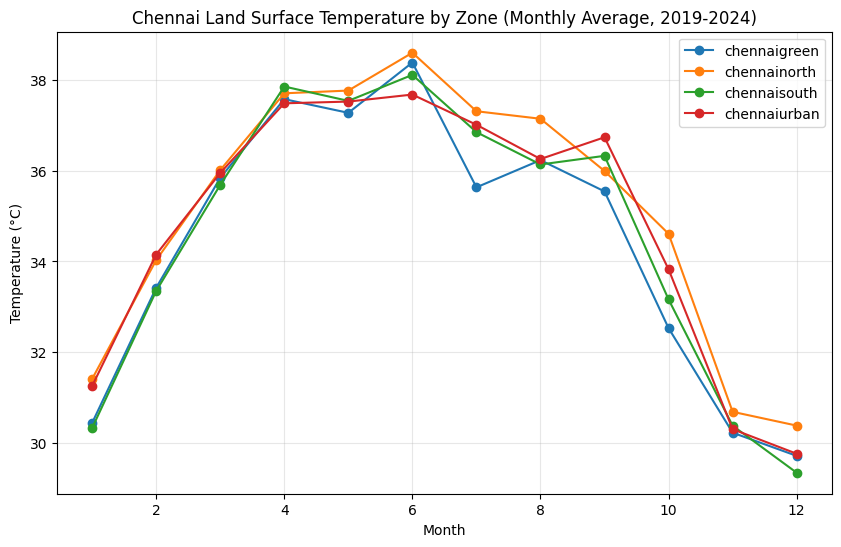

In [25]:
# Phase 5 - Step 1: Seasonal temperature trend by zone

monthly_zone = df_clean.groupby(['Month', 'ID'])['LST_Celsius'].mean().unstack()

plt.figure(figsize=(10,6))
for zone in monthly_zone.columns:
    plt.plot(monthly_zone.index, monthly_zone[zone], marker='o', label=zone)

plt.title('Chennai Land Surface Temperature by Zone (Monthly Average, 2019-2024)')
plt.xlabel('Month')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('/content/drive/MyDrive/chennaiproject/project/seasonal_trend.png', dpi=150, bbox_inches='tight')
plt.show()

ID    chennaigreen  chennainorth  chennaisouth  chennaiurban
Year                                                        
2018           NaN           NaN           NaN     25.970000
2019     35.432105     36.228947     34.814706     35.497895
2020     34.720909     35.597222     35.458000     35.368919
2021     34.957273     34.828750     34.938667     35.030000
2022     34.108286     34.355294     33.753571     34.474324
2023     33.860625     34.492286     33.580345     34.712222
2024     33.348667     34.010000     33.523043     33.573333


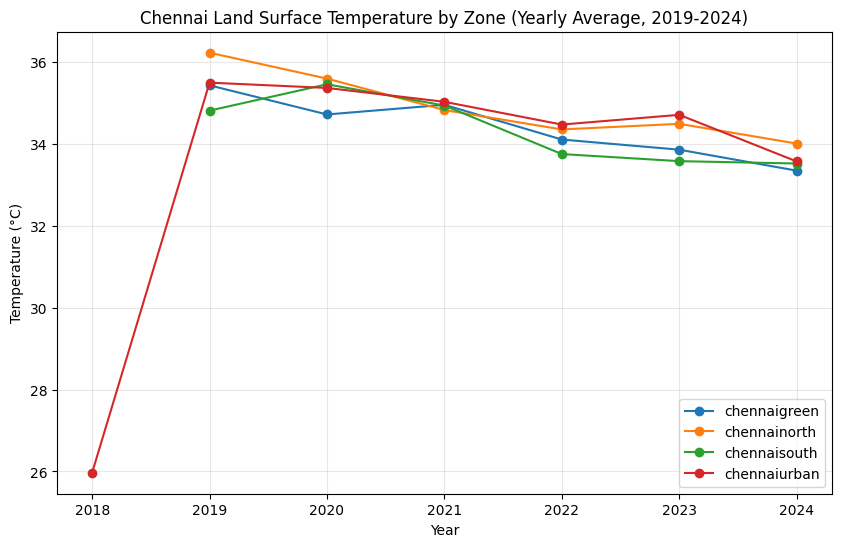

In [26]:
# Phase 5 - Step 2: Year-on-year warming trend by zone

yearly_zone = df_clean.groupby(['Year', 'ID'])['LST_Celsius'].mean().unstack()
print(yearly_zone)

plt.figure(figsize=(10,6))
for zone in yearly_zone.columns:
    plt.plot(yearly_zone.index, yearly_zone[zone], marker='o', label=zone)

plt.title('Chennai Land Surface Temperature by Zone (Yearly Average, 2019-2024)')
plt.xlabel('Year')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('/content/drive/MyDrive/chennaiproject/project/yearly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
# Phase 5 - Step 3: Interactive map of Chennai zones

zone_coords = {
    'chennaiurban': (13.08, 80.27),
    'chennainorth': (13.15, 80.28),
    'chennaisouth': (12.95, 80.20),
    'chennaigreen': (13.00, 80.22)
}

zone_avg_temp = df_clean.groupby('ID')['LST_Celsius'].mean()

m = folium.Map(location=[13.05, 80.25], zoom_start=11)

for zone, (lat, lon) in zone_coords.items():
    temp = zone_avg_temp[zone]
    color = 'red' if temp > 34.7 else ('orange' if temp > 34.4 else 'green')
    folium.CircleMarker(
        location=[lat, lon],
        radius=20,
        popup=f"{zone}: {temp:.2f}°C",
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.7
    ).add_to(m)

m.save('/content/drive/MyDrive/chennaiproject/project/chennai_heat_map.html')
m